# Requirements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk
import emoji
import spacy
import string
import tensorflow as tf
import datetime
from sklearn.utils import shuffle
from joblib import dump, load
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import CSVLogger, TensorBoard, EarlyStopping
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [2]:
# transformando e abrindo o arquivo em formato csv
df = pd.read_excel('DateToTestSentiment_20210817.xls.xls')

In [3]:
portuguese_stopwords = nltk.corpus.stopwords.words('portuguese')

# funções

In [4]:
def sentimento(x):
    """
    Função que transforma a coluna passada como argumento
    na variável target.
    """
    
    if x == 5:
        return 2
    elif x == 4:
        return 0
    else:
        return 1

def preprocess_text(text, remove_stop = True, 
                    stem_words = False, remove_mentions_hashtags = True):
    """
    eg:
    input: preprocess_text("@water #dream hi hello where are you going be there tomorrow happening happen happens",  
    stem_words = True) 
    output: ['tomorrow', 'happen', 'go', 'hello']
    """

    # Remove emojis
    emoji_pattern = re.compile("[" "\U0001F1E0-\U0001F6FF" "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r"", text)
    text = "".join([x for x in text if x not in emoji.UNICODE_EMOJI])

    if remove_mentions_hashtags:
        text = re.sub(r"@(\w+)", " ", text)
        text = re.sub(r"#(\w+)", " ", text)

    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    regex = re.compile('[' + re.escape(string.punctuation) + '0-9\\r\\t\\n]')
    nopunct = regex.sub(" ", text.lower())
    words = (''.join(nopunct)).split()

    if(remove_stop):
        words = [w for w in words if w not in portuguese_stopwords]
        words = [w for w in words if len(w) > 2]  

    if(stem_words):
        stemmer = PorterStemmer()
        words = [stemmer.stem(w) for w in words]

    return list(words)

# criando a coluna com o texto vetorizado
def vectorize2(lista):
    lista2 = [vectorize.vocabulary_[item] for item in lista]
    
    return lista2

def feelings_prediction():
    text = input("Digite seu texto aqui\n\n")
    text1 = preprocess_text(text)
    text1 = [vectorize2(text1)]
    text1 = tf.keras.preprocessing.sequence.pad_sequences(text1, maxlen=20)
    pred= model.predict(text1)
    predd = dict_feeling[np.argmax(pred)]
    print('\nSentimento analisado:', predd)

# Pré-processamento

In [5]:
# carrega o dataset apenas com as colunas desejadas
df = df[['COMMENT_TEXT','RATING_VALUE']]

df = df.dropna().reset_index().drop(columns=['index'])

# trata a coluna de rating para ficar apenas com dados float
for n, item in enumerate(df['RATING_VALUE']):
    if type(item) == str:
        df['RATING_VALUE'][n] = re.sub("[' ']","", df['RATING_VALUE'].iloc[n])
        df['RATING_VALUE'][n] = re.sub("[,]",".", df['RATING_VALUE'].iloc[n])
        
# transforma a coluna rating_value em float32
df['RATING_VALUE'] = df['RATING_VALUE'].astype('float32')

#
df1 = df.loc[df['RATING_VALUE'] == 5, :]

#
df2 = df.loc[df['RATING_VALUE'] != 5, :]

#
df1['RATING_VALUE'].value_counts(), df2['RATING_VALUE'].value_counts()

#
df1 = df1.sample(8062)

df_final = df1.append(df2).reset_index().drop(columns=['index'])

# organiza os labels pelo valor da rating dado pelo cliente
dict_feeling = {2: 'Positive', 1: 'Negative', 0: 'Neutral'}
   
# contruindo a coluna nova com os sentimentos
df_final['sentimentos'] = df_final['RATING_VALUE'].apply(sentimento)

# cria a coluna com textos vetorizados
rows, cols = df_final.shape

df_final['token'] = [preprocess_text(df_final["COMMENT_TEXT"][row]) for row in range(rows)]

# Vetorização

Como iremos fazer mais de um tipo de vetorização, vamos criar uma copia do dataset para utilizar nessa parte

In [6]:
# coleciona as palavras usadas para o treinamento da função CountVectorizer
lista_treino = []
for item in df_final['token']:
    lista_treino1 = [n for n in item if n not in lista_treino]
    lista_treino.extend(lista_treino1)
    
# treina o modelo de vetorização
vectorize = CountVectorizer(lowercase=True, strip_accents='unicode')

#
vectorize.fit(lista_treino)

#
df_final['vectors'] = df_final['token'].apply(vectorize2)

# Organizando os variáveis.

In [7]:
#
df_final = shuffle(df_final, random_state=42)

# separando as variaveis
X = df_final['vectors'].values

#
y = df_final['sentimentos'].values

# usa a função pad_sequences do keras para deixar todos os textos do mesmo tamanho
X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=20)

# separa os dados em treino e teste e fazendo o one-hot-encoding na variável y
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=42)

#
ytrain = tf.keras.utils.to_categorical(ytrain)

#
ytest = tf.keras.utils.to_categorical(ytest)

# Criando o modelo

In [8]:
#
model = tf.keras.Sequential()

#
model.add(tf.keras.layers.Embedding(input_dim=len(lista_treino)+1, 
                                    output_dim=128, input_shape=(Xtrain.shape[1],), 
                                    activity_regularizer=regularizers.l2(1e-5)))

#
model.add(tf.keras.layers.Dropout(0.25))

#
model.add(tf.keras.layers.LSTM(units=512, activation='relu'))

#
model.add(tf.keras.layers.Dense(units=256, activation='relu'))

#
model.add(tf.keras.layers.Dropout(0.25))

#
model.add(tf.keras.layers.Dense(units=128, activation='relu'))

#
model.add(tf.keras.layers.Dropout(0.25))

#
model.add(tf.keras.layers.Dense(units=64, activation='relu'))

#
model.add(tf.keras.layers.Dropout(0.25))

#
model.add(tf.keras.layers.Dense(units=3, activation='softmax', 
                                activity_regularizer=regularizers.l2(1e-5)))

#
model.compile(optimizer = 'Adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy']
             )

#
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 20, 128)           1286272   
_________________________________________________________________
dropout (Dropout)            (None, 20, 128)           0         
_________________________________________________________________
lstm (LSTM)                  (None, 512)               1312768   
_________________________________________________________________
dense (Dense)                (None, 256)               131328    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0

In [9]:
# criando um stopper para a rede
stopper = EarlyStopping(monitor="val_accuracy",
                         patience=5, verbose=2, mode='max')

callbacks = [stopper]

# Treinando o modelo

In [10]:
history = model.fit(x=Xtrain, 
                    y=ytrain, 
                    batch_size=128,
                    validation_data=(Xtest, ytest),
                    epochs=1,
                    callbacks=callbacks
                   )

114/114 [==============================] - 94s 815ms/step - loss: 0.9267 - accuracy: 0.5201 - val_loss: 0.8074 - val_accuracy: 0.6245


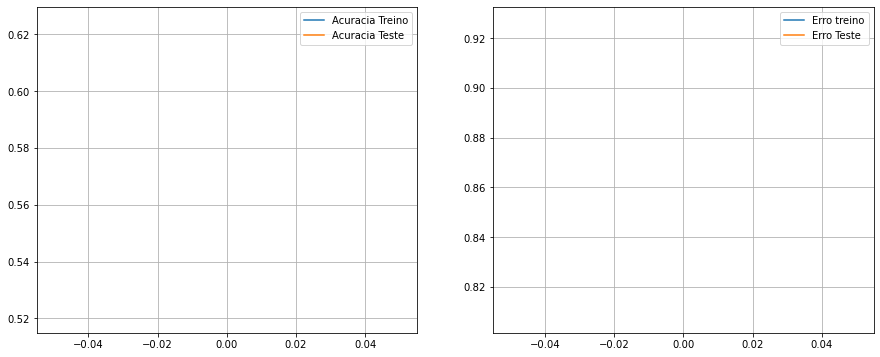

In [11]:
plt.figure(figsize=[15,6])

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Acuracia Treino')
plt.plot(history.history['val_accuracy'], label='Acuracia Teste')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Erro treino')
plt.plot(history.history['val_loss'], label='Erro Teste')
plt.legend()
plt.grid()



plt.show()

In [12]:
feelings_prediction()

Digite seu texto aqui

muito bom o tablet

Sentimento analisado: Neutral


In [13]:
feelings_prediction()

Digite seu texto aqui

não gostei muito do notebook

Sentimento analisado: Neutral


In [14]:
feelings_prediction()

Digite seu texto aqui

odiei o notebook

Sentimento analisado: Neutral


In [15]:
feelings_prediction()

Digite seu texto aqui

odiei

Sentimento analisado: Neutral


In [16]:
feelings_prediction()

Digite seu texto aqui

ok

Sentimento analisado: Positive


# Salvando Modelos

In [17]:
dump(vectorize, 'vetorize_sklearn.joblib') 

['vetorize_sklearn.joblib']

In [18]:
model.save('primeiro_modelo.h5')